# **MAT 4373: Project** </br> L1 vs. L2 regularization
Here we will be investigating the behaviour of regularization (L1 and L2 regularization) in a high dimensional environment, observing both correlated and uncorrelated datasets. We want to see how regularization performs under various conditions.

### **Dataset: An independent Gaussian design**
We generate synthetic data from a sparse linear model:

y = Xw* + ε

where:
- $X \in \mathbb{R}^{n \times d}$ is an orthonormal design matrix such that $X^\top X = I$, constructed via QR decomposition of a Gaussian matrix,
- $w^*$ is sparse, with only $s \ll d$ nonzero entries (e.g., the first $s$ coefficients are set to a constant signal),
- $\varepsilon \sim \mathcal{N}(0, \sigma^2 I)$ is Gaussian noise.


**Goal**  
We study:
- the bias of ridge regression and lasso
- compare the bias-variance tradeoffs

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Lasso, Ridge

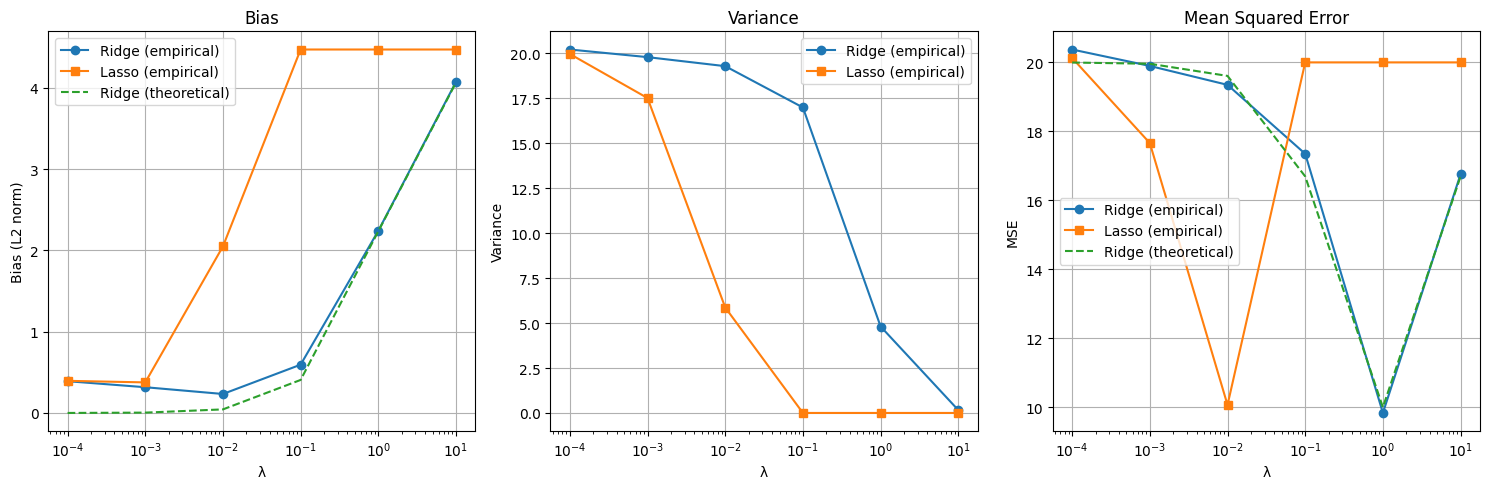

In [ ]:
# Simulation setup
n = 100
d = 20
sigma = 1.0
beta_true = np.zeros(d)
beta_true[:5] = 2.0                # sparse signal

# Orthonormal design
X = np.random.randn(n, d)
Q, _ = np.linalg.qr(X)
X = Q[:, :d]

num_trials = 200
alphas = [0.0001, 0.001, 0.01, 0.1, 1, 10]

# Storage for empirical results
ridge_bias = []
ridge_var = []
ridge_mse = []

lasso_bias = []
lasso_var = []
lasso_mse = []

for alpha in alphas:
    ridge_estimates = []
    lasso_estimates = []

    for _ in range(num_trials):
        noise = sigma * np.random.randn(n)
        y = X @ beta_true + noise

        ridge = Ridge(alpha=alpha, fit_intercept=False)
        ridge.fit(X, y)
        ridge_estimates.append(ridge.coef_)

        lasso = Lasso(alpha=alpha, fit_intercept=False, max_iter=10000)
        lasso.fit(X, y)
        lasso_estimates.append(lasso.coef_)

    # Ridge
    ridge_mean = np.mean(ridge_estimates, axis=0)
    ridge_bias.append(np.linalg.norm(ridge_mean - beta_true))
    ridge_var.append(np.mean([np.linalg.norm(c - ridge_mean)**2 for c in ridge_estimates]))
    ridge_mse.append(np.mean([np.linalg.norm(c - beta_true)**2 for c in ridge_estimates]))

    # Lasso
    lasso_mean = np.mean(lasso_estimates, axis=0)
    lasso_bias.append(np.linalg.norm(lasso_mean - beta_true))
    lasso_var.append(np.mean([np.linalg.norm(c - lasso_mean)**2 for c in lasso_estimates]))
    lasso_mse.append(np.mean([np.linalg.norm(c - beta_true)**2 for c in lasso_estimates]))

# Theoretical ridge (orthonormal design)
beta_norm2 = np.linalg.norm(beta_true)**2
theoretical_ridge_bias = []
theoretical_ridge_mse = []
for alpha in alphas:
    factor = alpha / (1 + alpha)
    bias_norm = factor * np.linalg.norm(beta_true)
    bias_sq = bias_norm**2
    var = d * sigma**2 / (1 + alpha)**2
    theoretical_ridge_bias.append(bias_norm)
    theoretical_ridge_mse.append(bias_sq + var)

# Plotting
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Bias
axes[0].plot(alphas, ridge_bias, 'o-', label='Ridge (empirical)')
axes[0].plot(alphas, lasso_bias, 's-', label='Lasso (empirical)')
axes[0].plot(alphas, theoretical_ridge_bias, '--', label='Ridge (theoretical)')
axes[0].set_xscale('log')
axes[0].set_xlabel('λ')
axes[0].set_ylabel('Bias (L2 norm)')
axes[0].set_title('Bias')
axes[0].legend()
axes[0].grid(True)

# Variance
axes[1].plot(alphas, ridge_var, 'o-', label='Ridge (empirical)')
axes[1].plot(alphas, lasso_var, 's-', label='Lasso (empirical)')
axes[1].set_xscale('log')
axes[1].set_xlabel('λ')
axes[1].set_ylabel('Variance')
axes[1].set_title('Variance')
axes[1].legend()
axes[1].grid(True)

# MSE
axes[2].plot(alphas, ridge_mse, 'o-', label='Ridge (empirical)')
axes[2].plot(alphas, lasso_mse, 's-', label='Lasso (empirical)')
axes[2].plot(alphas, theoretical_ridge_mse, '--', label='Ridge (theoretical)')
axes[2].set_xscale('log')
axes[2].set_xlabel('λ')
axes[2].set_ylabel('MSE')
axes[2].set_title('Mean Squared Error')
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.show()

- When λ is small, both ridge and lasso behave like OLS with small bias
- As λ increases, ridge increases steadily and lasso increases faster
- When λ is large, bias is large for both

This is the cost of regularization

# References
- scikit-learn Developers. (n.d.). recall_score.
https://scikit-learn.org/stable/modules/generated/sklearn.metrics.recall_score.html
- Singh, Y. (2022). Precision, Recall, and F1 Score: A Practical Guide Using Scikit-Learn. Proclus Academy.
https://proclusacademy.com/blog/practical/precision-recall-f1-score-sklearn/
- Evidently AI. (2025). Accuracy vs. precision vs. recall in machine learning: what's the difference?
https://www.evidentlyai.com/classification-metrics/accuracy-precision-recall
- DataCamp. (2022). Learning Curves Tutorial: What Are Learning Curves?
https://www.datacamp.com/fr/tutorial/tutorial-learning-curves
- Dataquest. (2018). Tutorial: Learning Curves for Machine Learning in Python for Data Science.
https://www.dataquest.io/blog/learning-curves-machine-learning/
- James, G., Witten, D., Hastie, T., Tibshirani, R., & Taylor, J. (2023). An Introduction to Statistical Learning with Applications in Python. Springer.
- DataCamp. (2022). Lasso and Ridge Regression in Python Tutorial.
https://www.datacamp.com/tutorial/tutorial-lasso-ridge-regression
- Bhuva, L. (2025). Understanding the Bias-Variance Tradeoff and Regularization in Machine Learning. Medium.
https://medium.com/@lomashbhuva/understanding-the-bias-variance-tradeoff-and-regularization-in-machine-learning-cdc5dd5e260e